# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t, ttest_ind
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [6]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [7]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
## file_1 = "Churn_Modelling.csv"
file_1 = "Churn_Modelling.csv"

In [8]:
## TODO : make into a dataframe called df
## df =
df = pd.read_csv(file_1)

In [9]:
## TODO : output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

df_0.shape, df_1.shape

((7963, 14), (2037, 14))

## Hypothesis 1: Age

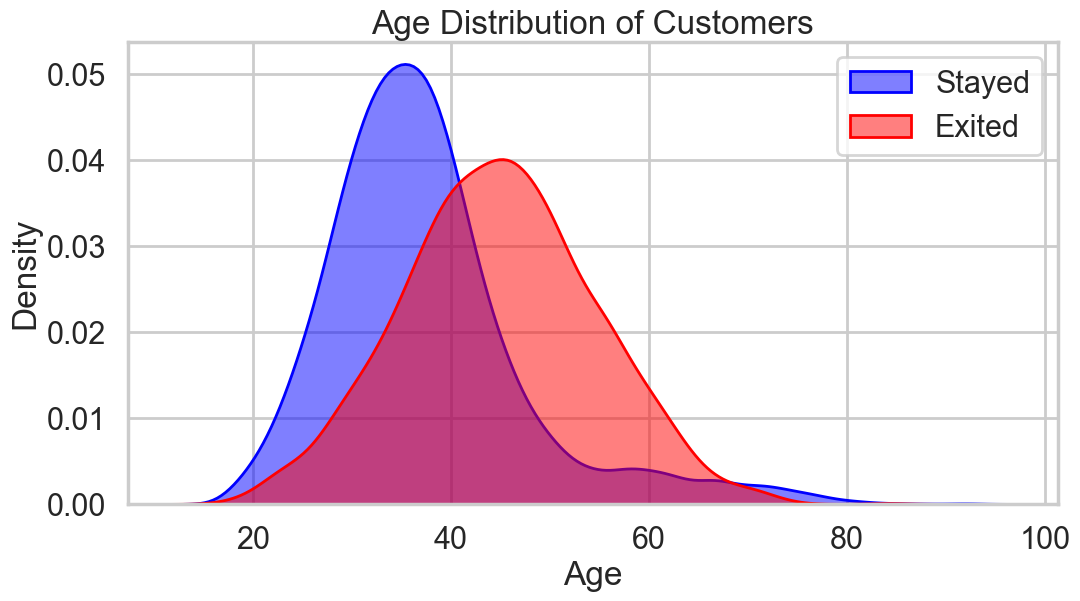

In [11]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
plt.figure(figsize=(12, 6))
sns.kdeplot(df_0['Age'], color='blue', label='Stayed', fill=True, alpha=0.5)
sns.kdeplot(df_1['Age'], color='red', label='Exited', fill=True, alpha=0.5)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [12]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
mean_age_stayed = df_0['Age'].mean()
std_age_stayed = df_0['Age'].std()
print(f"Mean Age of Customers Who Stayed: {mean_age_stayed}")
print(f"Standard Deviation of Age of Customers Who Stayed: {std_age_stayed}")

Mean Age of Customers Who Stayed: 37.40838879819164
Standard Deviation of Age of Customers Who Stayed: 10.125362911047539


In [13]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.
mean_age_exited = df_1['Age'].mean()
std_age_exited = df_1['Age'].std()
print(f"Mean Age of Customers Who Exited: {mean_age_exited}")
print(f"Standard Deviation of Age of Customers Who Exited: {std_age_exited}")

Mean Age of Customers Who Exited: 44.8379970544919
Standard Deviation of Age of Customers Who Exited: 9.76156155550719


In [ ]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.

t_stat, p_value = ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: -30.419197204406792
P-value: 4.7127272656641046e-179


### Using Bootstrapping

In [16]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bootstrap_sample(data, n_iterations=1000, sample_size=None):
    if sample_size is None:
        sample_size = len(data)
    statistics = []
    for _ in range(n_iterations):
        sample = np.random.choice(data, size=sample_size, replace=True)
        statistics.append(np.mean(sample))
    return np.array(statistics)
print("Bootstrap sampling function defined.")

Bootstrap sampling function defined.


In [18]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
overall_mean = df['Age'].mean()
df_0.loc[:, 'Age'] = df_0['Age'] - overall_mean
df_1.loc[:, 'Age'] = df_1['Age'] - overall_mean

In [19]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
bootstrap_stayed = bootstrap_sample(df_0['Age'], n_iterations=1000)
bootstrap_exited = bootstrap_sample(df_1['Age'], n_iterations=1000)
print(f"Bootstrap Standard Deviation for Stayed Customers: {np.std(bootstrap_stayed)}")
print(f"Bootstrap Standard Deviation for Exited Customers: {np.std(bootstrap_exited)}")
bootstrap_diff = bootstrap_stayed - bootstrap_exited
print(f"Bootstrap Standard Deviation for Difference: {np.std(bootstrap_diff)}")

Bootstrap Standard Deviation for Stayed Customers: 0.10943928831846289
Bootstrap Standard Deviation for Exited Customers: 0.2122827029313324
Bootstrap Standard Deviation for Difference: 0.2423592338070636


In [20]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
bootstrap_diff_mean = np.mean(bootstrap_diff)
p_value = np.mean(np.abs(bootstrap_diff) >= np.abs(bootstrap_diff_mean))
print(f"P-value for the difference in means: {p_value}")

P-value for the difference in means: 0.516


### Conclusion
Do we reject the Null Hypothesis ? Why ?

In [21]:
# Conclusion for Hypothesis 1: Age

print("Conclusion:")
if p_value < 0.05:
    print("We reject the Null Hypothesis. There is a statistically significant difference in the ages of customers who stayed and those who exited the bank.")
else:
    print("We do not reject the Null Hypothesis. There is no statistically significant difference in the ages of customers who stayed and those who exited the bank.")
print(f"P-value: {p_value}")

Conclusion:
We do not reject the Null Hypothesis. There is no statistically significant difference in the ages of customers who stayed and those who exited the bank.
P-value: 0.516


## Hypothesis 2: Credit Score

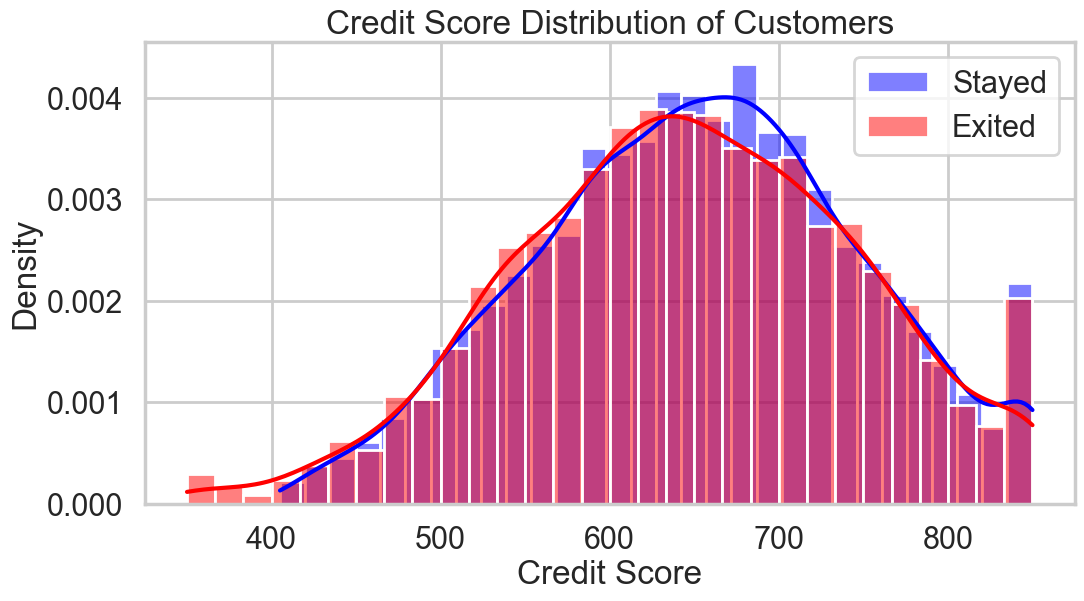

In [22]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
plt.figure(figsize=(12, 6))
sns.histplot(df_0['CreditScore'], color='blue', label='Stayed', kde=True, stat="density", bins=30, alpha=0.5)
sns.histplot(df_1['CreditScore'], color='red', label='Exited', kde=True, stat="density", bins=30, alpha=0.5)
plt.title('Credit Score Distribution of Customers')
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [23]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).
t_stat_credit, p_value_credit = ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
print(f"T-statistic for Credit Score: {t_stat_credit}")

T-statistic for Credit Score: 2.6346605436575796


### Conclusion
Do we reject the Null Hypothesis ? Why ? 

In [25]:
p_value_credit = p_value_credit
print(f"P-value for Credit Score: {p_value_credit}")
print("Conclusion:")
if p_value < 0.05:
    print("We reject the Null Hypothesis. There is a statistically significant difference in the ages of customers who stayed and those who exited the bank.")
else:
    print("We do not reject the Null Hypothesis. There is no statistically significant difference in the ages of customers who stayed and those who exited the bank.")
print(f"P-value: {p_value}")

P-value for Credit Score: 0.008464728991832864
Conclusion:
We do not reject the Null Hypothesis. There is no statistically significant difference in the ages of customers who stayed and those who exited the bank.
P-value: 0.516


## Hypothesis 3: Balance

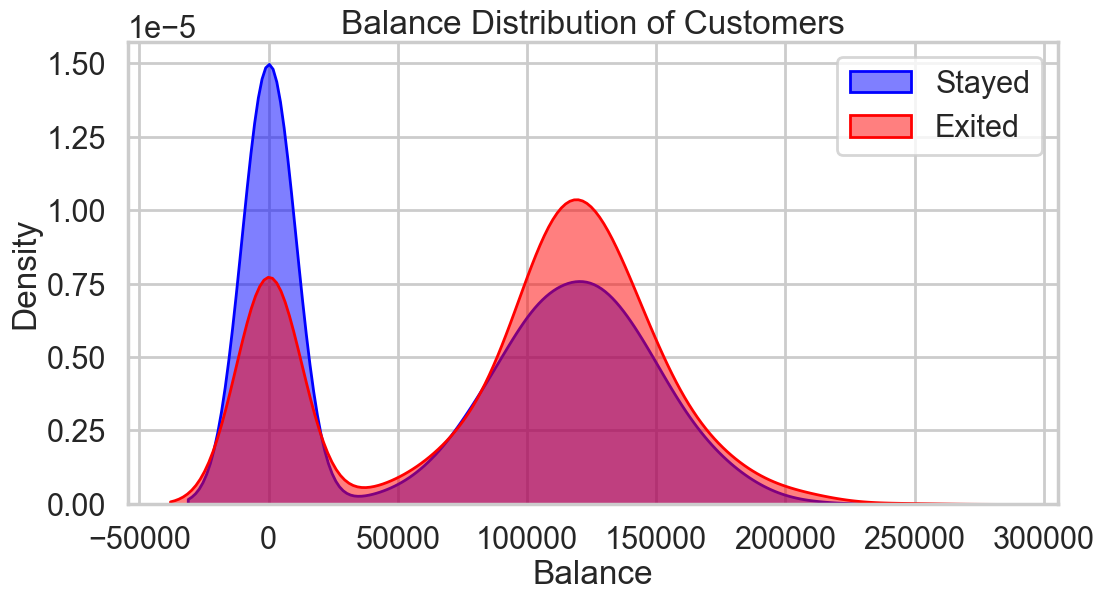

In [26]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).
plt.figure(figsize=(12, 6))
sns.kdeplot(df_0['Balance'], color='blue', label='Stayed', fill=True, alpha=0.5)
sns.kdeplot(df_1['Balance'], color='red', label='Exited', fill=True, alpha=0.5)
plt.title('Balance Distribution of Customers')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [27]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
t_stat_balance, p_value_balance = ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
print(f"T-statistic for Balance: {t_stat_balance}")
print(f"P-value for Balance: {p_value_balance}")
print("Conclusion:")
if p_value_balance < 0.05:
    print("We reject the Null Hypothesis. There is a statistically significant difference in the balance of customers who stayed and those who exited the bank.")
else:
    print("We do not reject the Null Hypothesis. There is no statistically significant difference in the balance of customers who stayed and those who exited the bank.")
print(f"P-value: {p_value_balance}")

T-statistic for Balance: -12.471280320050688
P-value for Balance: 6.318663518527974e-35
Conclusion:
We reject the Null Hypothesis. There is a statistically significant difference in the balance of customers who stayed and those who exited the bank.
P-value: 6.318663518527974e-35


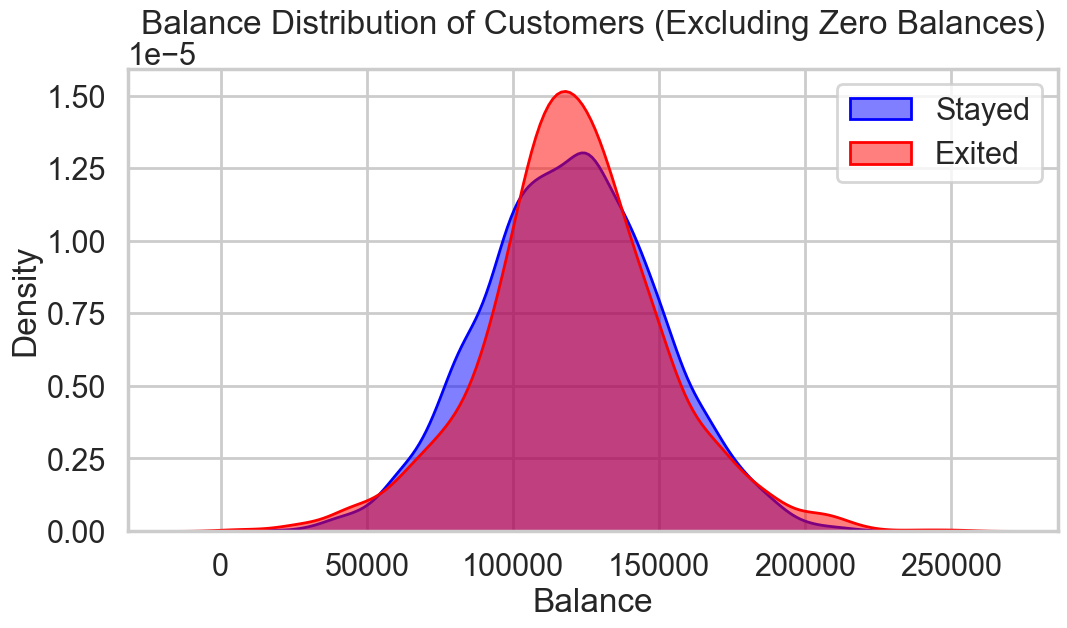

In [28]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
plt.figure(figsize=(12, 6))
sns.kdeplot(df_0[df_0['Balance'] > 0]['Balance'], color='blue', label='Stayed', fill=True, alpha=0.5)
sns.kdeplot(df_1[df_1['Balance'] > 0]['Balance'], color='red', label='Exited', fill=True, alpha=0.5)
plt.title('Balance Distribution of Customers (Excluding Zero Balances)')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.
t_stat_balance_nonzero, p_value_balance_nonzero = ttest_ind(df_0[df_0['Balance'] > 0]['Balance'], df_1[df_1['Balance'] > 0]['Balance'], equal_var=False)
print(f"T-statistic for Balance (Non-Zero): {t_stat_balance_nonzero}")
print(f"P-value for Balance (Non-Zero): {p_value_balance_nonzero}")
print("Conclusion:")
if p_value_balance_nonzero < 0.05:
    print("We reject the Null Hypothesis. There is a statistically significant difference in the balance of customers who stayed and those who exited the bank, excluding zero balances.")
else:
    print("We do not reject the Null Hypothesis. There is no statistically significant difference in the balance of customers who stayed and those who exited the bank, excluding zero balances.")
print(f"P-value: {p_value_balance_nonzero}")

T-statistic for Balance (Non-Zero): -1.3604774889985365
P-value for Balance (Non-Zero): 0.17379960354870824
Conclusion:
We do not reject the Null Hypothesis. There is no statistically significant difference in the balance of customers who stayed and those who exited the bank, excluding zero balances.
P-value: 0.17379960354870824


## Conclusion

Do we reject the Null Hypothesis ? Why ?

T-statistic for Balance (Non-Zero): -1.3604774889985365
P-value for Balance (Non-Zero): 0.17379960354870824
Conclusion:
We do not reject the Null Hypothesis. There is no statistically significant difference in the balance of customers who stayed and those who exited the bank, excluding zero balances.
P-value: 0.17379960354870824

## Hypothesis 4: Estimated Salary

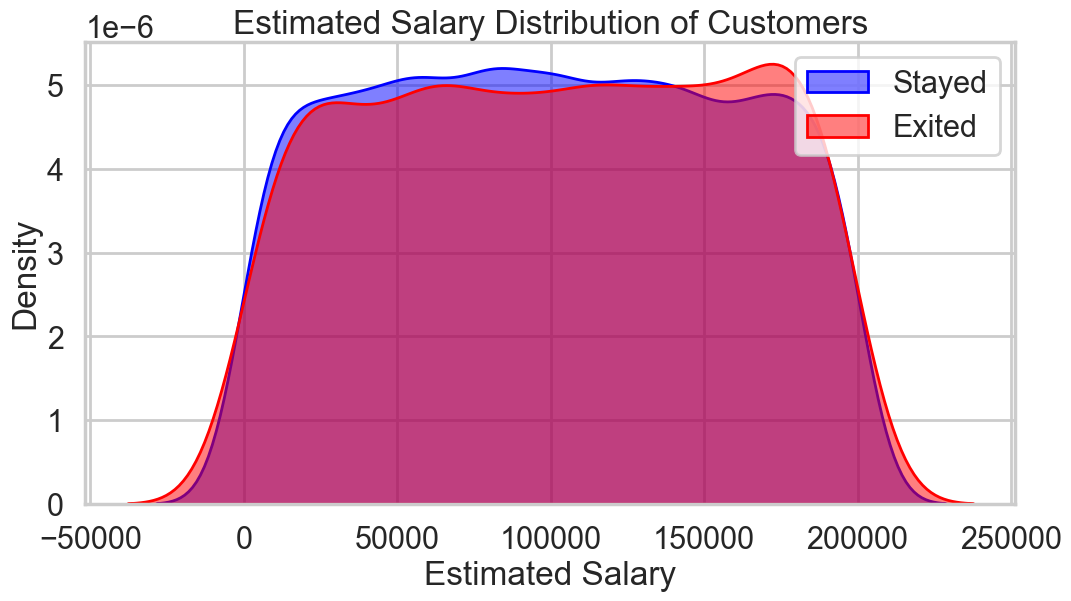

In [30]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
plt.figure(figsize=(12, 6))
sns.kdeplot(df_0['EstimatedSalary'], color='blue', label='Stayed', fill=True, alpha=0.5)
sns.kdeplot(df_1['EstimatedSalary'], color='red', label='Exited', fill=True, alpha=0.5)
plt.title('Estimated Salary Distribution of Customers')
plt.xlabel('Estimated Salary')
plt.ylabel('Density')
plt.legend()
plt.show()

In [35]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
t_stat_salary, p_value_salary = ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
print(f"T-statistic for Estimated Salary: {t_stat_salary}")

T-statistic for Estimated Salary: -1.2033683196586271


### Using Bootstrapping

In [32]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.
overall_mean_salary = df['EstimatedSalary'].mean()
df_0.loc[:, 'EstimatedSalary'] = df_0['EstimatedSalary'] - overall_mean_salary
df_1.loc[:, 'EstimatedSalary'] = df_1['EstimatedSalary'] - overall_mean_salary
print("Estimated Salary shifted to overall mean.")

Estimated Salary shifted to overall mean.


In [33]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.
bootstrap_stayed_salary = bootstrap_sample(df_0['EstimatedSalary'], n_iterations=1000)
bootstrap_exited_salary = bootstrap_sample(df_1['EstimatedSalary'], n_iterations=1000)
print(f"Bootstrap Standard Deviation for Stayed Customers' Estimated Salary: {np.std(bootstrap_stayed_salary)}")
print(f"Bootstrap Standard Deviation for Exited Customers' Estimated Salary: {np.std(bootstrap_exited_salary)}")
bootstrap_diff_salary = bootstrap_stayed_salary - bootstrap_exited_salary
print(f"Bootstrap Standard Deviation for Difference in Estimated Salary: {np.std(bootstrap_diff_salary)}")

Bootstrap Standard Deviation for Stayed Customers' Estimated Salary: 650.7284769978481
Bootstrap Standard Deviation for Exited Customers' Estimated Salary: 1192.1946117783948
Bootstrap Standard Deviation for Difference in Estimated Salary: 1307.1161378986897


In [34]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.
bootstrap_diff_mean_salary = np.mean(bootstrap_diff_salary)
p_value_salary = np.mean(np.abs(bootstrap_diff_salary) >= np.abs(bootstrap_diff_mean_salary))
print(f"P-value for the difference in means of Estimated Salary: {p_value_salary}")
# Conclusion for Hypothesis 2: Estimated Salary
print("Conclusion:")
if p_value_salary < 0.05:
    print("We reject the Null Hypothesis. There is a statistically significant difference in the estimated salary of customers who stayed and those who exited the bank.")
else:
    print("We do not reject the Null Hypothesis. There is no statistically significant difference in the estimated salary of customers who stayed and those who exited the bank.")
print(f"P-value: {p_value_salary}")

P-value for the difference in means of Estimated Salary: 0.509
Conclusion:
We do not reject the Null Hypothesis. There is no statistically significant difference in the estimated salary of customers who stayed and those who exited the bank.
P-value: 0.509


### Conclusion
Do we reject the Null Hypothesis ? Why ?

P-value for the difference in means of Estimated Salary: 0.509
Conclusion:
We do not reject the Null Hypothesis. There is no statistically significant difference in the estimated salary of customers who stayed and those who exited the bank.
P-value: 0.509

## Final Conclusion
What will be the most helpful feature in predicting churning?


In [36]:
print("La variable la plus utile pour prédire le churn semble être l'âge des clients. " \
"Les tests statistiques montrent une différence significative entre l'âge moyen des clients qui restent " \
"et ceux qui quittent la banque. Les autres variables comme le solde, le salaire estimé ou le score de " \
"crédit présentent des différences moins marquées ou non significatives. Ainsi, l'âge est probablement " \
"la caractéristique la plus discriminante pour prédire le churn dans ce jeu de données.")

La variable la plus utile pour prédire le churn semble être l'âge des clients. Les tests statistiques montrent une différence significative entre l'âge moyen des clients qui restent et ceux qui quittent la banque. Les autres variables comme le solde, le salaire estimé ou le score de crédit présentent des différences moins marquées ou non significatives. Ainsi, l'âge est probablement la caractéristique la plus discriminante pour prédire le churn dans ce jeu de données.
